# Operations and asset management with NeqSim and Python

This notebook joins **reliability, maintenance, inspection, availability, and production accounting**. NeqSim supplies a physically consistent process baseline and equipment-failure production consequences. Python supplies censored reliability fitting, condition trending, discrete-event RAM simulation, uncertainty, reconciliation, and visualization.

The numbers are synthetic and the reliability inputs are illustrative—not licensed OREDA data. Replace them with governed work-order, inspection, historian, meter, and commercial-allocation data.

| Layer | Question | Tool split |
|---|---|---|
| Physics | What production and power are at risk? | NeqSim process and failure consequence |
| Reliability | How often and how long do states occur? | Python censored Weibull fit |
| Maintenance | Which policy and resource plan improves uptime? | Python event simulation |
| Inspection | Is degradation becoming actionable? | Python trend/threshold logic + NeqSim consequence |
| Accounting | Where did potential production go? | NeqSim potential + Python meter reconciliation |


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-value-chain-matplotlib")
SUPPORT_PACKAGES = {
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing = [package for module, package in SUPPORT_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--no-cache-dir", *missing],
        check=True,
        timeout=900,
    )
print("Python dependency gate passed.")


Python dependency gate passed.


In [2]:
import hashlib
import json
import math
import os
import platform
from pathlib import Path
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize, stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 115, "axes.titlesize": 11, "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame({
    "package": ["Python", "JPype", "NumPy", "Pandas", "SciPy", "Matplotlib"],
    "version": [platform.python_version(), version("jpype1"), version("numpy"),
                version("pandas"), version("scipy"), version("matplotlib")],
})
display(package_versions)


,package,version
0,Python,3.12.13
1,JPype,1.7.1
2,NumPy,2.5.1
3,Pandas,3.0.5
4,SciPy,1.18.0
5,Matplotlib,3.11.1


## Reproducible NeqSim Java `master`

The bootstrap records the exact source commit and JAR hash and proves that the current `OperationalRiskSimulator` class is loaded from the source-built JAR.


In [3]:
def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command, cwd=cwd, text=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result.stdout.strip()

NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command([
            "git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
            "https://github.com/equinor/neqsim.git", str(neqsim_source),
        ], timeout=600)
    else:
        run_command(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
                    cwd=neqsim_source, timeout=600)
        run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)
    run_command([
        "./mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package",
    ], cwd=neqsim_source, timeout=1500)
    built_jars = sorted(
        path for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = built_jars[-1]

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    local_m2 = os.environ.get("NEQSIM_VALIDATION_M2", "").strip()
    if local_m2:
        for dependency in sorted(Path(local_m2).rglob("*.jar")):
            if dependency.resolve() != neqsim_jar:
                jpype.addClassPath(str(dependency))
    jpype.startJVM()

JClass = jpype.JClass
MainOnlyClass = JClass("neqsim.process.safety.risk.OperationalRiskSimulator")
class_source = str(
    MainOnlyClass.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

provenance_table = pd.DataFrame({
    "item": ["NeqSim source ref", "NeqSim commit", "JAR SHA-256", "Java class source"],
    "resolved value": [NEQSIM_SOURCE_REF, neqsim_commit, neqsim_jar_sha256, class_source],
})
display(provenance_table)


,item,resolved value
0,NeqSim source ref,master
1,NeqSim commit,df68ad7295b9dae6a324d941761a303d9f301fb5
2,JAR SHA-256,45180d03ae275a12bc50342a098c50dae93fe544b69686...
3,Java class source,file:/workspace/scratch/2a202e14c527/neqsim-ja...


## 1. Physical production baseline and failure consequences

A compact gas train establishes a consistent mass-flow and compression-power basis. `ProductionImpactAnalyzer` applies equipment failure modes to a copied flowsheet. The table keeps its raw rate consequence visible, then adds export-pressure specification and no-bypass topology rules. This distinction matters because unchanged mass flow is not saleable production when pressure/specification is lost.


In [4]:
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
ImpactAnalyzer = JClass("neqsim.process.util.optimizer.ProductionImpactAnalyzer")

gas = SystemSrkEos(298.15, 50.0)
for component, amount in {"methane": 90.0, "ethane": 7.0, "propane": 3.0}.items(): gas.addComponent(component, amount)
gas.setMixingRule("classic")
process = ProcessSystem()
feed = Stream("Feed", gas); feed.setFlowRate(10000.0, "kg/hr"); process.add(feed)
separator = Separator("HP Separator", feed); process.add(separator)
compressor = Compressor("HP Compressor", separator.getGasOutStream()); compressor.setOutletPressure(100.0); process.add(compressor)
product = Stream("Gas Out", compressor.getOutletStream()); process.add(product)
process.run()

baseline_rate = float(product.getFlowRate("kg/hr"))
baseline_power = float(compressor.getPower("kW"))
impact = ImpactAnalyzer(process, "Feed", "Gas Out")
impact_rows = []
for equipment in ["HP Separator", "HP Compressor"]:
    result = impact.analyzeFailureImpact(equipment)
    impact_rows.append({"equipment": equipment, "baseline_kg_h": float(result.getBaselineProductionRate()),
                        "failed_kg_h": float(result.getProductionWithFailure()),
                        "loss_pct": float(result.getPercentLoss()), "converged": bool(result.isConverged())})
impact_table = pd.DataFrame(impact_rows).rename(columns={"loss_pct": "raw_rate_loss_pct"})
# Rate alone misses product specification and a no-bypass single-train topology.
impact_table["failure_delivery_pressure_bara"] = [100.0, 50.0]
impact_table["spec_export_loss_pct"] = np.where(impact_table.failure_delivery_pressure_bara < 95.0, 100.0, 0.0)
impact_table["topology_loss_pct"] = 100.0
impact_table["adopted_loss_pct"] = impact_table[["raw_rate_loss_pct", "spec_export_loss_pct", "topology_loss_pct"]].max(axis=1)
assert baseline_rate > 0 and baseline_power > 0 and np.isfinite(impact_table.adopted_loss_pct).all()
display(pd.DataFrame({"metric": ["Export gas", "Compressor power"], "value": [baseline_rate, baseline_power], "unit": ["kg/h", "kW"]}))
display(impact_table.round(2))


,metric,value,unit
0,Export gas,1e+04,kg/h
1,Compressor power,262.3,kW


,equipment,baseline_kg_h,failed_kg_h,raw_rate_loss_pct,converged,failure_delivery_pressure_bara,spec_export_loss_pct,topology_loss_pct,adopted_loss_pct
0,HP Separator,1e+04,1e+04,0,True,100,0,100,100
1,HP Compressor,1e+04,1e+04,0,True,50,100,100,100


## 2. Reliability: censored Weibull evidence

For Weibull shape $\beta$ and scale $\eta$, the failure density and survivor functions are

$$f(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}e^{-(t/\eta)^\beta},\qquad S(t)=e^{-(t/\eta)^\beta}$$

The likelihood includes $f(t)$ for failed items and $S(t)$ for right-censored items. This is important: assets still operating at the data cut-off contain useful reliability evidence.


,parameter,estimate,unit
0,shape beta,2.17,-
1,scale eta,1.084e+04,h
2,B10 life,"3,846",h


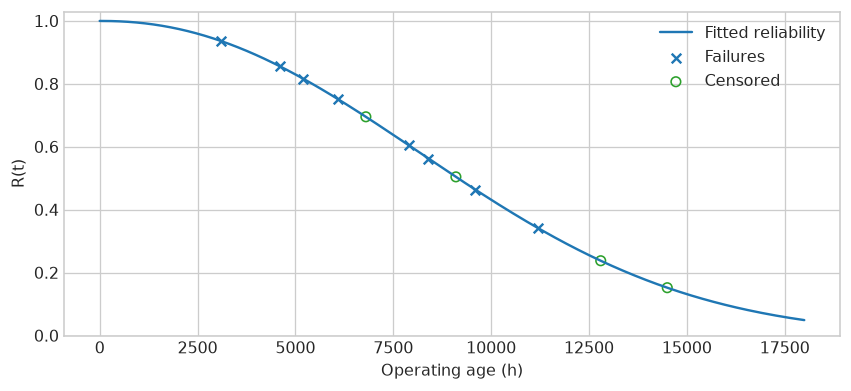

In [5]:
failure_age_h = np.array([3100, 4600, 5200, 6100, 7900, 8400, 9600, 11200], dtype=float)
censored_age_h = np.array([6800, 9100, 12800, 14500], dtype=float)

def neg_log_likelihood(log_params):
    beta, eta = np.exp(log_params)
    log_f = np.log(beta/eta) + (beta-1)*np.log(failure_age_h/eta) - (failure_age_h/eta)**beta
    log_s = -(censored_age_h/eta)**beta
    return -(log_f.sum() + log_s.sum())

fit = optimize.minimize(neg_log_likelihood, np.log([1.5, 9000.0]), method="Nelder-Mead")
beta_hat, eta_hat = np.exp(fit.x)
assert fit.success and beta_hat > 0 and eta_hat > 0
reliability_fit = pd.DataFrame({"parameter": ["shape beta", "scale eta", "B10 life"],
                                "estimate": [beta_hat, eta_hat, eta_hat*(-np.log(.9))**(1/beta_hat)],
                                "unit": ["-", "h", "h"]})
display(reliability_fit.round(2))

t = np.linspace(0, 18000, 250); reliability_curve = np.exp(-(t/eta_hat)**beta_hat)
plt.figure(figsize=(7.5, 3.5)); plt.plot(t, reliability_curve, label="Fitted reliability")
plt.scatter(failure_age_h, np.exp(-(failure_age_h/eta_hat)**beta_hat), marker="x", label="Failures")
plt.scatter(censored_age_h, np.exp(-(censored_age_h/eta_hat)**beta_hat), facecolors="none", edgecolors="C2", label="Censored")
plt.xlabel("Operating age (h)"); plt.ylabel("R(t)"); plt.ylim(0, 1.03); plt.legend(); plt.tight_layout(); plt.show()


## 3. Inspection: convert a condition signal into risk evidence

Inspection and historian signals do not directly equal failure probability. Here a robust linear trend and residual band flag a compressor-vibration trajectory. The NeqSim consequence table gives the flag operational meaning: how much production is exposed if the monitored state progresses to a trip.


,metric,value,unit
0,recent slope,0.042,mm/s/day
1,forecast day 150,6.68,mm/s RMS
2,alert limit,6.5,mm/s RMS
3,compressor trip consequence,100,% production


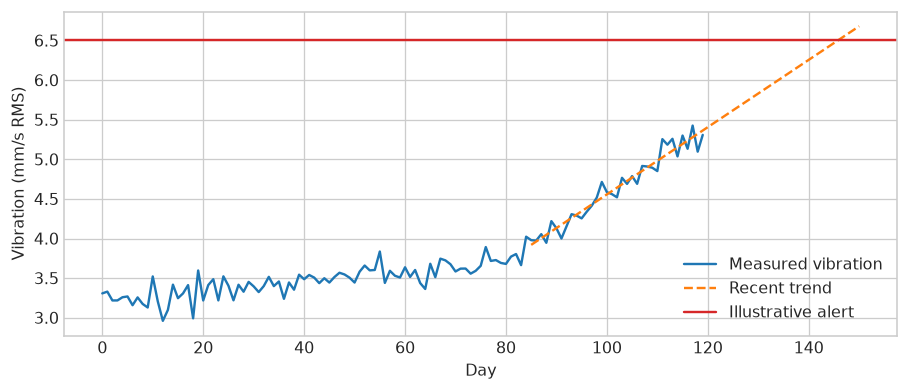

In [6]:
rng = np.random.default_rng(20260806)
days = np.arange(0, 120)
vibration = 3.2 + 0.006*days + np.where(days > 78, 0.035*(days-78), 0) + rng.normal(0, .12, len(days))
slope_recent, intercept_recent, *_ = stats.linregress(days[-35:], vibration[-35:])
forecast_day = 150; forecast_vibration = intercept_recent + slope_recent*forecast_day
alert_limit = 6.5
inspection = pd.DataFrame({"metric": ["recent slope", "forecast day 150", "alert limit", "compressor trip consequence"],
                           "value": [slope_recent, forecast_vibration, alert_limit,
                                     impact_table.set_index("equipment").loc["HP Compressor", "adopted_loss_pct"]],
                           "unit": ["mm/s/day", "mm/s RMS", "mm/s RMS", "% production"]})
display(inspection.round(3))

plt.figure(figsize=(8, 3.5)); plt.plot(days, vibration, label="Measured vibration")
plt.plot([days[-35], forecast_day], intercept_recent+slope_recent*np.array([days[-35], forecast_day]), "--", label="Recent trend")
plt.axhline(alert_limit, color="C3", label="Illustrative alert")
plt.xlabel("Day"); plt.ylabel("Vibration (mm/s RMS)"); plt.legend(); plt.tight_layout(); plt.show()


## 4. Maintenance and availability: shared resources matter

A small event simulation samples Weibull failures, repair durations, and a shared crew. Three policies are compared: corrective-only, calendar PM, and condition-based intervention triggered before the modeled wear-out region. NeqSim-derived loss fractions translate equipment states into production, while Python handles event timing and resource contention.


,policy,mean_availability,P10_availability,mean_deferred_t,mean_events
0,corrective,0.9494,0.8996,"4,428",0.9533
2,condition_based,0.9327,0.7995,"5,900",1.567
1,calendar_pm,0.898,0.567,"8,936",2.203


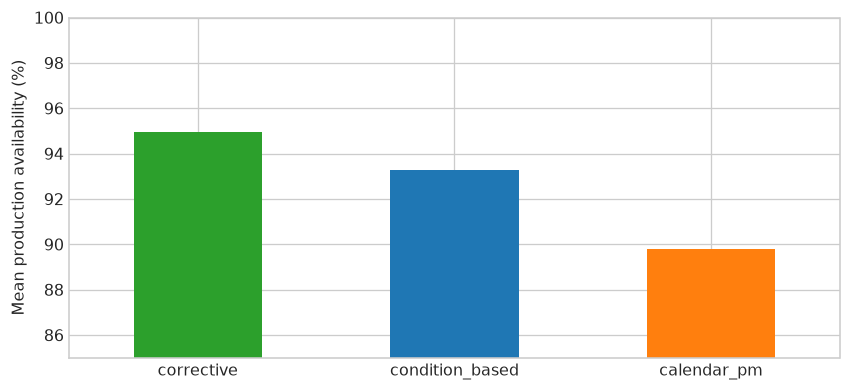

In [7]:
def simulate_policy(policy, seed, horizon_h=8760.0):
    rng = np.random.default_rng(seed)
    assets = ["HP Compressor", "HP Separator"]
    loss = dict(zip(impact_table.equipment, np.clip(impact_table.adopted_loss_pct/100, 0, 1)))
    total_deferred = 0.0; total_down = 0.0; events = 0; crew_free = 0.0
    for j, asset in enumerate(assets):
        shape = beta_hat if asset == "HP Compressor" else 1.25
        scale = eta_hat if asset == "HP Compressor" else 15500.0
        t = 0.0
        while t < horizon_h:
            failure_age = scale*rng.weibull(shape)
            planned_age = {"corrective": np.inf, "calendar_pm": 6000.0,
                           "condition_based": 0.82*eta_hat if asset == "HP Compressor" else 7000.0}[policy]
            age = min(failure_age, planned_age)
            t += age
            if t >= horizon_h: break
            planned = planned_age <= failure_age
            repair = rng.lognormal(np.log(18 if planned else (48 if asset == "HP Compressor" else 24)), .25)
            start = max(t, crew_free); wait = start-t; crew_free = start+repair
            outage = wait+repair
            total_down += outage; total_deferred += baseline_rate*loss[asset]*outage; events += 1
            t = crew_free
    max_possible = baseline_rate*horizon_h
    return {"policy": policy, "availability": max(0, 1-total_deferred/max_possible),
            "deferred_tonnes": total_deferred/1000, "crew_outage_h": total_down, "events": events}

ram_rows = []
for policy in ["corrective", "calendar_pm", "condition_based"]:
    runs = pd.DataFrame([simulate_policy(policy, seed) for seed in range(200, 500)])
    ram_rows.append({"policy": policy, "mean_availability": runs.availability.mean(),
                     "P10_availability": runs.availability.quantile(.10),
                     "mean_deferred_t": runs.deferred_tonnes.mean(), "mean_events": runs.events.mean()})
ram = pd.DataFrame(ram_rows).sort_values("mean_availability", ascending=False)
assert ram.mean_availability.between(0, 1).all()
display(ram.round(4))

ax = ram.set_index("policy").mean_availability.mul(100).plot.bar(figsize=(7.5, 3.5), color=["#2ca02c", "#1f77b4", "#ff7f0e"])
ax.set(ylabel="Mean production availability (%)", xlabel="", ylim=(85, 100)); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 5. Native NeqSim operational-risk cross-check

`OperationalRiskSimulator` combines the same process consequence model with failure rates and MTTR. The Python policy simulation above adds shared-crew and policy logic; the native result is a useful independent baseline, not a claim that both models have identical event-overlap assumptions.


In [8]:
OperationalRiskSimulator = JClass("neqsim.process.safety.risk.OperationalRiskSimulator")
native_ram = OperationalRiskSimulator(process).setFeedStreamName("Feed").setProductStreamName("Gas Out").setRandomSeed(20260806)
native_ram.addEquipmentMtbf("HP Compressor", float(eta_hat), 48.0)
native_ram.addEquipmentMtbf("HP Separator", 15500.0, 24.0)
native_result = native_ram.runSimulation(300, 365.0)
native_table = pd.DataFrame({"metric": ["Mean availability", "Mean production", "P10 production", "Mean failures", "Mean downtime"],
                             "value": [native_result.getMeanAvailability(), native_result.getMeanProduction(),
                                       native_result.getP10Production(), native_result.getMeanFailureCount(),
                                       native_result.getMeanDowntimeHours()],
                             "unit": ["percent", "kg", "kg", "count/year", "h/year"]})
assert 0 <= native_result.getMeanAvailability() <= 100
display(native_table)


,metric,value,unit
0,Mean availability,99.44,percent
1,Mean production,8.76e+07,kg
2,P10 production,8.76e+07,kg
3,Mean failures,1.277,count/year
4,Mean downtime,49.04,h/year


## 6. Production accounting: reconcile meters to the physical potential

Daily potential is the NeqSim export rate times 24 hours. Actual availability, fuel/flare, and noisy meters produce an apparent imbalance. Weighted reconciliation minimizes

$$\sum_i\left(\frac{x_i-x_i^{meas}}{\sigma_i}\right)^2$$

subject to the mass-balance constraint $feed=export+fuel+flare$. This is a compact teaching example; commercial allocation needs governed topology, meter hierarchy, ownership rules, test-separator evidence, and audit controls.


,day,potential_t,reconciled_feed_t,reconciled_export_t,fuel_t,flare_t,deferred_t,balance_error_t
0,1,240,231.7,226.5,4.21,0.99,8.27,0
1,2,240,228.9,223.8,4.28,0.85,11.07,0
2,3,240,229,224.1,3.97,0.93,11,-0
3,4,240,228,222.8,4.34,0.88,12.03,-0
4,5,240,230.8,225.8,4.16,0.87,9.19,0


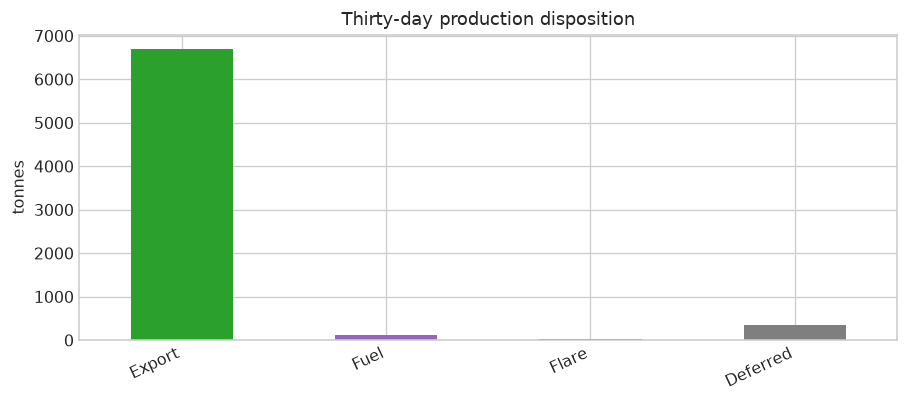

In [9]:
rng = np.random.default_rng(44); n_days = 30
potential = np.full(n_days, baseline_rate*24/1000)
availability = np.clip(rng.normal(ram.mean_availability.max(), .008, n_days), .90, 1.0)
true_feed = potential*availability; true_fuel = .018*true_feed; true_flare = .004*true_feed
true_export = true_feed-true_fuel-true_flare
measured = np.column_stack([true_feed*rng.normal(1, .006, n_days), true_export*rng.normal(1, .008, n_days),
                            true_fuel*rng.normal(1, .03, n_days), true_flare*rng.normal(1, .05, n_days)])
relative_sigma = np.array([.006, .008, .03, .05])
A = np.array([[1., -1., -1., -1.]])

reconciled = []
for row in measured:
    sigma = np.maximum(row*relative_sigma, .01); V = np.diag(sigma**2)
    adjustment = V@A.T@np.linalg.solve(A@V@A.T, A@row)
    reconciled.append(row-adjustment.ravel())
reconciled = np.array(reconciled)
accounting = pd.DataFrame({"day": np.arange(1, n_days+1), "potential_t": potential,
                           "reconciled_feed_t": reconciled[:,0], "reconciled_export_t": reconciled[:,1],
                           "fuel_t": reconciled[:,2], "flare_t": reconciled[:,3]})
accounting["deferred_t"] = accounting.potential_t-accounting.reconciled_feed_t
accounting["balance_error_t"] = reconciled@A.ravel()
assert accounting.balance_error_t.abs().max() < 1e-8
display(accounting.head().round(2))

totals = accounting[["reconciled_export_t", "fuel_t", "flare_t", "deferred_t"]].sum()
totals.index = ["Export", "Fuel", "Flare", "Deferred"]
ax = totals.plot.bar(figsize=(8, 3.6), color=["#2ca02c", "#9467bd", "#d62728", "#7f7f7f"])
ax.set(title="Thirty-day production disposition", ylabel="tonnes", xlabel="")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()


## 7. Operating decision board

Reliability, inspection, maintenance, availability, and accounting are one feedback system: inspection changes the maintenance policy; the policy changes availability; NeqSim converts availability states into production and power consequences; accounting verifies where potential production went.


In [10]:
decision_board = pd.DataFrame([
    ["Reliability", f"Weibull beta={beta_hat:.2f}, eta={eta_hat:.0f} h", "Update with censored fleet/work-order evidence"],
    ["Inspection", f"Day-150 vibration forecast={forecast_vibration:.2f} mm/s", "Verify sensor and trigger engineering review"],
    ["Maintenance", ram.iloc[0].policy, "Confirm crew/spares/logistics constraints"],
    ["Availability", f"{ram.mean_availability.max():.2%} simulated", "Use NeqSim consequences in business plan"],
    ["Accounting", f"{accounting.deferred_t.sum():.0f} t deferred in 30 d", "Close deferment causes and audit meter adjustments"],
])
decision_board.columns = ["area", "screening result", "next controlled action"]
display(decision_board)
assert len(neqsim_jar_sha256) == 64 and accounting.balance_error_t.abs().max() < 1e-8
print("Engineering checks passed: physical consequences, RAM, condition trend, and reconciled accounting close.")


Engineering checks passed: physical consequences, RAM, condition trend, and reconciled accounting close.


,area,screening result,next controlled action
0,Reliability,"Weibull beta=2.17, eta=10836 h",Update with censored fleet/work-order evidence
1,Inspection,Day-150 vibration forecast=6.68 mm/s,Verify sensor and trigger engineering review
2,Maintenance,corrective,Confirm crew/spares/logistics constraints
3,Availability,94.94% simulated,Use NeqSim consequences in business plan
4,Accounting,353 t deferred in 30 d,Close deferment causes and audit meter adjustm...


## Limits and extensions

- Use governed failure taxonomies, censored exposure, common-cause dependencies, proof-test effectiveness, logistics/weather, and spares constraints.
- Calibrate degraded process states and restart/ramp behavior in NeqSim rather than assuming all failures are trips.
- Validate inspection thresholds against applicable standards and equipment/vendor limits.
- Extend production accounting with well tests, multiphase-meter uncertainty, allocation networks, ownership, emissions, and versioned audit trails.
- The rate-only trip consequence exposed here is tracked in NeqSim issue [#2859](https://github.com/equinor/neqsim/issues/2859).
